# Chapter 20: Duality

Source orientation: printed pages 502-514; physical PDF pages 520-532.

This notebook is an original, standalone computational treatment of Chapter 20. The source span was used to identify the chapter's structure and terminology: Carlsson-Weinshall duality, reduced camera matrices, the dual reconstruction algorithm, reduced fundamental and trifocal tensors, and the conditioning problems caused by canonical image transformations. No textbook prose, figures, screenshots, page crops, or exercise text are copied.

## Chapter Goal

Make Carlsson-Weinshall duality inspectable. A reduced camera has four free parameters, and in that coordinate frame the product `P @ X` is symmetric enough that a camera-parameter vector can be read as a point in a dual reconstruction problem while a world point can be read as a reduced camera. The notebook builds that swap, tracks how image transformations preserve incidence while changing numerical conditioning, and checks the reduced tensor constraints that make six- and seven-point dual reconstruction algorithms possible.

## Library Routing

| Chapter concept | Representation | Library choice | Why this route | Check |
| --- | --- | --- | --- | --- |
| Reduced camera dual swap | Matrix heatmaps plus vector equality | NumPy, Matplotlib | The symmetry is a concrete matrix product. | `P(a,b,c,d) X == P_star(X) (a,b,c,d)`. |
| Point-plane-camera incidence | Interactive 3D camera ray and back-projected planes | Plotly | A learner needs to rotate the camera center, 3D point, image plane, and planes. | `l.T @ P @ X == (P.T @ l).T @ X`. |
| Canonical image transformations | Projective basis diagram and conditioning curve | NumPy, Matplotlib | Homographies preserve incidence but can amplify numerical risk. | Anchors map to `e_k`; transformed lines still contain transformed points. |
| Dual algorithm bookkeeping | Transpose-and-extend table plus incidence graph | NetworkX, Matplotlib | The algorithm is an index swap with four synthetic rows. | Measurement-edge counts and degree multisets are preserved. |
| Reduced dual tensors | Reduced fundamental matrix and constrained trifocal nullspace | SymPy, NumPy, Matplotlib | SymPy checks exact constraints; SVD shows numerical nullspaces. | Reduced `F` has zero synthetic residuals and determinant zero; reduced trifocal candidate satisfies `C t = 0`. |

## Translation Guide

- A 3D point is a homogeneous vector `X = (X, Y, Z, T)`. A reduced camera is `P(a,b,c,d)`, with nonzero parameters chosen so the four basis points `E_1,...,E_4` project to the image basis `e_1,...,e_4`.
- The dual swap is projective, not metric: the image vector produced by a reduced camera and a point is unchanged if the camera parameters and point coordinates exchange roles in the reduced template.
- Image transformations `T_i` in the dual algorithm are homographies. They preserve point-line incidence and cross-product zero tests, but they can severely distort the numerical scale of image noise.
- The transposed array in the dual algorithm is a relabeling of the same transformed measurements. The four synthetic `e_k` rows force the solved dual cameras to be reduced.
- A reduced fundamental matrix is a two-view tensor already satisfying the four synthetic correspondences `e_k <-> e_k`. A reduced trifocal tensor is handled by exact linear constraints `C t = 0` plus a least-squares data term.

## Chapter-Specific Storyboard

| Visual | Artifact | What to inspect | Validation |
| --- | --- | --- | --- |
| Reduced camera dual swap | `figures/reduced-camera-dual-swap.png` | The same image coordinates are produced by a primal reduced camera and the dual reduced camera built from the world point. | Dual product residual below `1e-12`; basis projections match the canonical image basis. |
| Point-plane-camera incidence | `interactive/point-plane-camera-incidence.html` | Image lines through a projected point back-project to 3D planes meeting along the camera ray. | Back-projected plane incidence residuals below `1e-12`. |
| Canonical frame transform | `figures/canonical-frame-incidence-transform.png` | Four selected image points become the projective basis, and lines through anchors remain incidence lines after transformation. | Homography cross-product residual and transformed line residual below tolerance. |
| Dual transpose and extension | `figures/dual-algorithm-transpose-extend.png` | The original `m` views of `n+4` points become `n` views of `m+4` points. | Edge counts and degree multisets match under the point-view swap. |
| Reduced fundamental tensor | `figures/reduced-fundamental-dual-tensor.png` | The zero diagonal, zero sum, rank-two condition, and same-image dual equations all constrain one reduced `F`. | Synthetic `e_k` residuals, determinant, SVD solve residuals, and recovered-camera residuals are small. |
| Reduced trifocal constraints | `figures/reduced-trifocal-constraint-nullspace.png` | Exact synthetic constraints form a nullspace before noisy data constraints are minimized. | `C t = 0` for the constrained solution. |
| Canonical transform conditioning | `figures/canonical-transform-conditioning.png` | A near-collinear anchor set makes the canonicalizing homography ill-conditioned. | Homography condition ratio rises as the minimum anchor triangle area shrinks. |

In [1]:
from pathlib import Path
import sys

BOOK_ROOT = Path.cwd()
for candidate in [BOOK_ROOT, *BOOK_ROOT.parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find the MVG book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

TOPIC = "chapter-20"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / TOPIC
for subdir in ["figures", "interactive", "checks", "tables"]:
    (ARTIFACT_ROOT / subdir).mkdir(parents=True, exist_ok=True)

artifact_paths = []
check_paths = []
ARTIFACT_ROOT.relative_to(BOOK_ROOT)

WindowsPath('artifacts/chapter-20')

In [2]:
import itertools
import math

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import plotly.graph_objects as go
import sympy as sp

from utils.artifacts import assert_artifacts, display_artifact, save_json, save_matplotlib, save_plotly_html

plt.rcParams.update({"figure.dpi": 140, "font.size": 10})

E3_IMAGE = np.array([[1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0], [1.0, 1.0, 1.0]])
E4_WORLD = np.eye(4)
TRIANGLE_CHART = np.array([[0.0, 0.0], [1.0, 0.0], [0.5, math.sqrt(3.0) / 2.0]])

def reduced_camera(params):
    a, b, c, d = np.asarray(params, dtype=float)
    return np.array([[a, 0.0, 0.0, d], [0.0, b, 0.0, d], [0.0, 0.0, c, d]])

def dual_camera_from_point(point):
    X, Y, Z, T = np.asarray(point, dtype=float)
    return np.array([[X, 0.0, 0.0, T], [0.0, Y, 0.0, T], [0.0, 0.0, Z, T]])

def projective_cross_residual(a, b):
    a = np.asarray(a, dtype=float).reshape(3)
    b = np.asarray(b, dtype=float).reshape(3)
    return float(np.linalg.norm(np.cross(a, b)) / max(np.linalg.norm(a) * np.linalg.norm(b), 1e-12))

def dehomogeneous(points_h):
    pts = np.asarray(points_h, dtype=float)
    if pts.ndim == 1:
        pts = pts.reshape(1, -1)
    return pts[:, :-1] / pts[:, -1:]

def simplex_chart(points_h):
    pts = np.asarray(points_h, dtype=float)
    if pts.ndim == 1:
        pts = pts.reshape(1, -1)
    scale = pts.sum(axis=1, keepdims=True)
    if np.any(np.abs(scale) < 1e-12):
        raise ValueError("simplex chart undefined for a point with zero coordinate sum")
    return (pts / scale) @ TRIANGLE_CHART

def homography_from_homogeneous_points(source_h, target_h):
    rows = []
    for x, xp in zip(np.asarray(source_h, dtype=float), np.asarray(target_h, dtype=float)):
        cross_xp = np.array([[0.0, -xp[2], xp[1]], [xp[2], 0.0, -xp[0]], [-xp[1], xp[0], 0.0]])
        for row in cross_xp:
            rows.append(np.kron(row, x))
    A = np.asarray(rows, dtype=float)
    _, singular_values, Vt = np.linalg.svd(A)
    return Vt[-1].reshape(3, 3), singular_values

def transformed_line(H, line):
    return np.linalg.inv(H).T @ np.asarray(line, dtype=float)

def point_line_incidence(line, point):
    line = np.asarray(line, dtype=float).reshape(3)
    point = np.asarray(point, dtype=float).reshape(3)
    return float(abs(line @ point) / max(np.linalg.norm(line) * np.linalg.norm(point), 1e-12))

def min_anchor_triangle_area(points_h):
    pts = dehomogeneous(points_h)
    areas = []
    for i, j, k in itertools.combinations(range(len(pts)), 3):
        areas.append(abs(np.linalg.det(np.vstack([pts[j] - pts[i], pts[k] - pts[i]]))) / 2.0)
    return float(min(areas))

def reduced_F_from_camera_params(params):
    a, b, c, d = np.asarray(params, dtype=float)
    return np.array([[0.0, b * (d - c), -c * (d - b)], [-a * (d - c), 0.0, c * (d - a)], [a * (d - b), -b * (d - a), 0.0]])

def reduced_F_template(theta):
    p, q, r, s, t = np.asarray(theta, dtype=float)
    return np.array([[0.0, p, q], [r, 0.0, s], [t, -(p + q + r + s + t), 0.0]])

F_BASIS = [reduced_F_template(np.eye(5)[i]) for i in range(5)]

def theta_from_reduced_F(F):
    F = np.asarray(F, dtype=float)
    return np.array([F[0, 1], F[0, 2], F[1, 0], F[1, 2], F[2, 0]])

def reduced_F_equation_row(x, y):
    return np.array([np.asarray(y) @ B @ np.asarray(x) for B in F_BASIS], dtype=float)

def point_on_line(line, parameter):
    a, b, c = np.asarray(line, dtype=float).reshape(3)
    if abs(b) > 1e-10:
        return np.array([parameter, -(a * parameter + c) / b, 1.0])
    return np.array([-(b * parameter + c) / a, parameter, 1.0])

def null_vector(A):
    _, _, Vt = np.linalg.svd(np.asarray(A, dtype=float))
    return Vt[-1]

def scaled_relative_error(estimate, truth):
    estimate = np.asarray(estimate, dtype=float).ravel()
    truth = np.asarray(truth, dtype=float).ravel()
    scale = float(truth @ estimate / max(estimate @ estimate, 1e-15))
    return float(np.linalg.norm(scale * estimate - truth) / max(np.linalg.norm(truth), 1e-15)), scale

def recover_reduced_camera_params_from_F(F):
    F = np.asarray(F, dtype=float)
    abc_matrix = np.array([[F[0, 1], F[1, 0], 0.0], [F[0, 2], 0.0, F[2, 0]], [0.0, F[1, 2], F[2, 1]]])
    abc_ratio = null_vector(abc_matrix)
    d_minus_ratio = null_vector(F.T)
    A, B, C = abc_ratio
    U, V, W = d_minus_ratio
    lam, mu = null_vector(np.array([[A - B, U - V], [A - C, U - W]], dtype=float))
    return np.array([lam * A, lam * B, lam * C, lam * A + mu * U])

def levi_civita(i, j, k):
    if len({i, j, k}) < 3:
        return 0
    perm = [i, j, k]
    inversions = sum(1 for a in range(3) for b in range(a + 1, 3) if perm[a] > perm[b])
    return -1 if inversions % 2 else 1

def trifocal_point_constraint_rows(x, xp, xpp):
    x = np.asarray(x, dtype=float).reshape(3)
    xp = np.asarray(xp, dtype=float).reshape(3)
    xpp = np.asarray(xpp, dtype=float).reshape(3)
    rows = []
    for r in range(3):
        for s in range(3):
            coeff = np.zeros(27)
            for i in range(3):
                for j in range(3):
                    for k in range(3):
                        total = 0.0
                        for p in range(3):
                            for q in range(3):
                                total += x[i] * xp[p] * xpp[q] * levi_civita(j, p, r) * levi_civita(k, q, s)
                        coeff[i * 9 + j * 3 + k] = total
            rows.append(coeff)
    return np.vstack(rows)

def matrix_heatmap(ax, M, title):
    M = np.asarray(M, dtype=float)
    vmax = max(1e-12, np.max(np.abs(M)))
    ax.imshow(M, cmap="coolwarm", vmin=-vmax, vmax=vmax)
    ax.set_title(title)
    ax.set_xticks(range(M.shape[1]))
    ax.set_yticks(range(M.shape[0]))
    for (r, c), value in np.ndenumerate(M):
        ax.text(c, r, f"{value:.2f}", ha="center", va="center", fontsize=8)

In [3]:
visual_storyboard = {
    "chapter": "20 Duality",
    "source_span": "PDF pages 520-532, printed pages 502-514",
    "visuals": [
        "reduced camera dual swap",
        "point-plane-camera incidence",
        "incidence-preserving canonical image transform",
        "dual algorithm transpose and extension",
        "reduced fundamental matrix as a dual tensor",
        "reduced trifocal tensor exact constraints",
        "canonical transformation conditioning",
    ],
    "artifact_root": "artifacts/chapter-20",
}
storyboard_path = save_json(visual_storyboard, TOPIC, "checks", "visual-storyboard.json")
check_paths.append(storyboard_path)
display_artifact(storyboard_path)
visual_storyboard

`artifacts/chapter-20/checks/visual-storyboard.json`

{'chapter': '20 Duality',
 'source_span': 'PDF pages 520-532, printed pages 502-514',
 'visuals': ['reduced camera dual swap',
  'point-plane-camera incidence',
  'incidence-preserving canonical image transform',
  'dual algorithm transpose and extension',
  'reduced fundamental matrix as a dual tensor',
  'reduced trifocal tensor exact constraints',
  'canonical transformation conditioning'],
 'artifact_root': 'artifacts/chapter-20'}

## 1. Reduced Camera Dual Swap

A reduced camera sends the four world basis points to the four image basis points. In that frame, the product with a point has the form `(a X + d T, b Y + d T, c Z + d T)`. This is also the result of a reduced camera built from the point coordinates acting on the camera-parameter vector `(a,b,c,d)`.

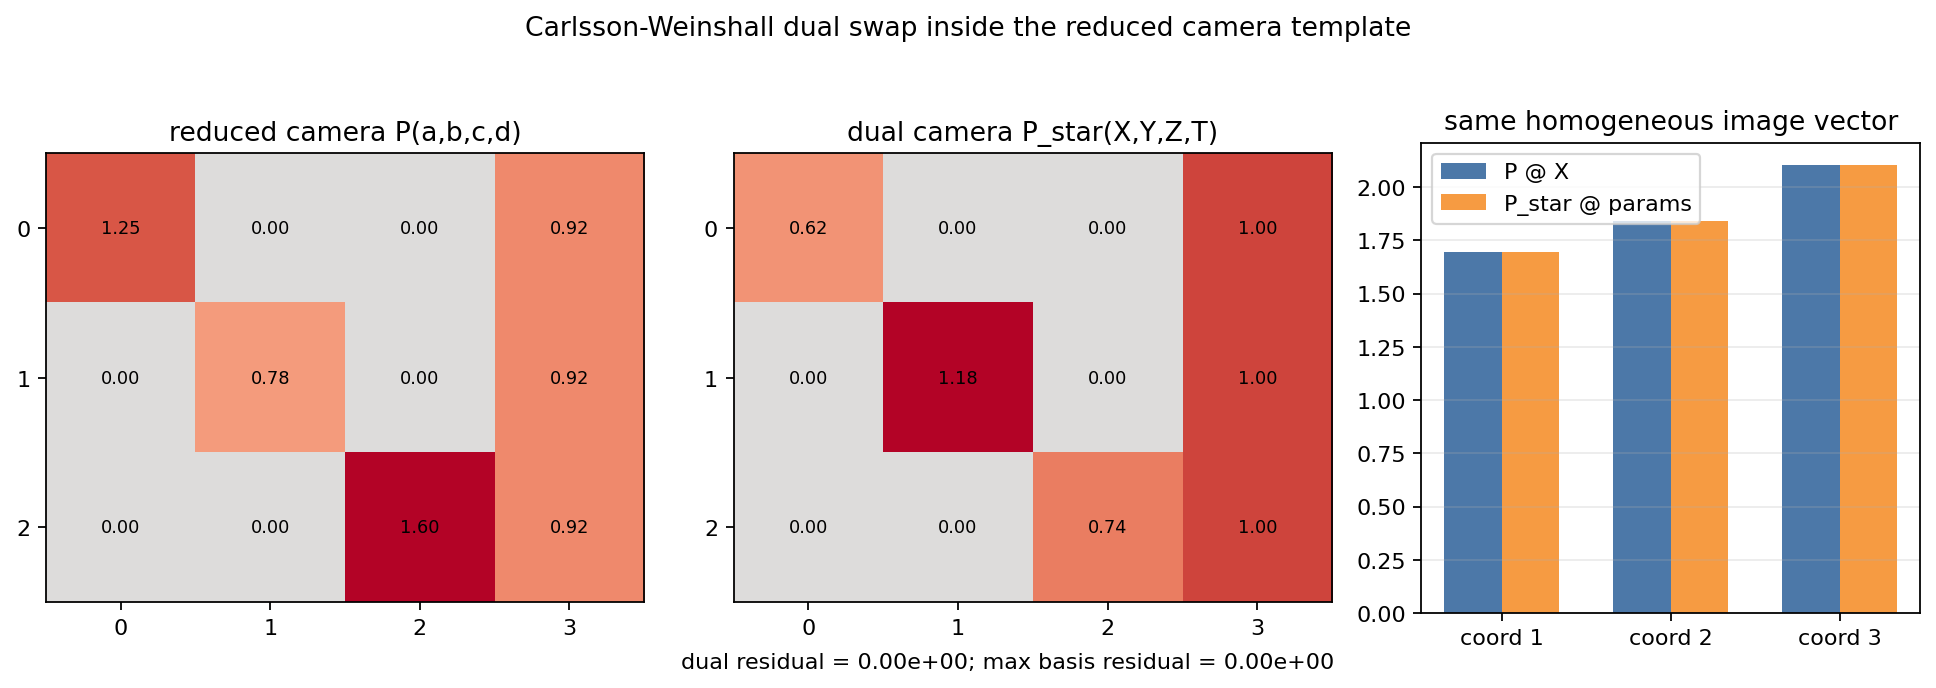

{'dual_swap_residual': 0.0, 'basis_projection_residuals': [0.0, 0.0, 0.0, 0.0]}

In [4]:
camera_params = np.array([1.25, 0.78, 1.60, 0.92])
world_point = np.array([0.62, 1.18, 0.74, 1.0])
P_reduced = reduced_camera(camera_params)
P_dual_from_point = dual_camera_from_point(world_point)
primal_image_vector = P_reduced @ world_point
dual_image_vector = P_dual_from_point @ camera_params
dual_swap_residual = float(np.linalg.norm(primal_image_vector - dual_image_vector))

basis_projected = (P_reduced @ E4_WORLD.T).T
basis_projection_residuals = [projective_cross_residual(basis_projected[i], E3_IMAGE[i]) for i in range(4)]

fig, axes = plt.subplots(1, 3, figsize=(12.2, 4.0), gridspec_kw={"width_ratios": [1.2, 1.2, 1.0]})
matrix_heatmap(axes[0], P_reduced, "reduced camera P(a,b,c,d)")
matrix_heatmap(axes[1], P_dual_from_point, "dual camera P_star(X,Y,Z,T)")
coords = np.arange(3)
axes[2].bar(coords - 0.17, primal_image_vector, width=0.34, label="P @ X", color="#4c78a8")
axes[2].bar(coords + 0.17, dual_image_vector, width=0.34, label="P_star @ params", color="#f58518", alpha=0.82)
axes[2].set_xticks(coords)
axes[2].set_xticklabels(["coord 1", "coord 2", "coord 3"])
axes[2].set_title("same homogeneous image vector")
axes[2].legend(frameon=True)
axes[2].grid(axis="y", alpha=0.25)
fig.suptitle("Carlsson-Weinshall dual swap inside the reduced camera template", y=1.03)
fig.text(0.52, 0.01, f"dual residual = {dual_swap_residual:.2e}; max basis residual = {max(basis_projection_residuals):.2e}", ha="center")
fig.tight_layout()

swap_path = save_matplotlib(fig, TOPIC, "figures", "reduced-camera-dual-swap.png")
plt.close(fig)
artifact_paths.append(swap_path)
display_artifact(swap_path, width=900)

{"dual_swap_residual": dual_swap_residual, "basis_projection_residuals": basis_projection_residuals}

## 2. Point-Plane-Camera Incidence

If an image line `l` passes through `x = P X`, then `l.T @ P @ X = 0`. The same scalar can be read in 3D as `(P.T @ l).T @ X = 0`, where `P.T @ l` is the plane back-projected from the image line. Two image lines through `x` become two 3D planes whose intersection is the camera ray through `X`.

In [5]:
P_pinhole = np.hstack([np.eye(3), np.zeros((3, 1))])
X_incident = np.array([0.72, 0.44, 3.15, 1.0])
x_image = P_pinhole @ X_incident
x_image = x_image / x_image[2]
line_a = np.cross(x_image, np.array([x_image[0] + 0.55, x_image[1] - 0.18, 1.0]))
line_b = np.cross(x_image, np.array([x_image[0] - 0.30, x_image[1] + 0.48, 1.0]))
planes = [P_pinhole.T @ line_a, P_pinhole.T @ line_b]
plane_incidence_residuals = [float(abs(plane @ X_incident)) for plane in planes]
image_line_residuals = [float(abs(line @ x_image)) for line in [line_a, line_b]]

surface_x = np.linspace(-0.25, 1.05, 18)
surface_y = np.linspace(-0.20, 0.80, 18)
XX, YY = np.meshgrid(surface_x, surface_y)
plane_surfaces = [-(plane[0] * XX + plane[1] * YY + plane[3]) / plane[2] for plane in planes]

fig = go.Figure()
fig.add_trace(go.Surface(x=[[-0.10, 1.05], [-0.10, 1.05]], y=[[-0.10, -0.10], [0.85, 0.85]], z=[[1.0, 1.0], [1.0, 1.0]], showscale=False, opacity=0.22, colorscale=[[0, "#d7e6f5"], [1, "#d7e6f5"]], name="image plane"))
for ZZ, color, name in zip(plane_surfaces, ["#7fc97f", "#beaed4"], ["plane from line a", "plane from line b"]):
    fig.add_trace(go.Surface(x=XX, y=YY, z=ZZ, showscale=False, opacity=0.34, colorscale=[[0, color], [1, color]], name=name))
for line, color, name in [(line_a, "#1b9e77", "image line a"), (line_b, "#6a3d9a", "image line b")]:
    u = np.linspace(-0.05, 1.0, 50)
    v = -(line[0] * u + line[2]) / line[1]
    fig.add_trace(go.Scatter3d(x=u, y=v, z=np.ones_like(u), mode="lines", line={"color": color, "width": 6}, name=name))
fig.add_trace(go.Scatter3d(x=[0.0], y=[0.0], z=[0.0], mode="markers+text", marker={"size": 6, "color": "black"}, text=["camera center"], name="camera center"))
fig.add_trace(go.Scatter3d(x=[X_incident[0]], y=[X_incident[1]], z=[X_incident[2]], mode="markers+text", marker={"size": 6, "color": "#d95f02"}, text=["X"], name="3D point"))
fig.add_trace(go.Scatter3d(x=[x_image[0]], y=[x_image[1]], z=[1.0], mode="markers+text", marker={"size": 5, "color": "#e7298a"}, text=["x = PX"], name="image point"))
fig.add_trace(go.Scatter3d(x=[0.0, X_incident[0]], y=[0.0, X_incident[1]], z=[0.0, X_incident[2]], mode="lines", line={"color": "#333333", "width": 7}, name="camera ray"))
fig.update_layout(title="Point-plane-camera incidence", scene={"xaxis_title": "X", "yaxis_title": "Y", "zaxis_title": "Z", "aspectmode": "data"}, margin={"l": 0, "r": 0, "t": 45, "b": 0})

incidence_html_path = save_plotly_html(fig, TOPIC, "interactive", "point-plane-camera-incidence.html")
artifact_paths.append(incidence_html_path)
display_artifact(incidence_html_path, width=900, height=560)

{"max_image_line_residual": max(image_line_residuals), "max_backprojected_plane_residual": max(plane_incidence_residuals)}

.venv/Lib/site-packages/IPython/core/display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


{'max_image_line_residual': 0.0,
 'max_backprojected_plane_residual': 5.551115123125783e-17}

## 3. Canonical Image Frames Preserve Incidence

The dual algorithm starts by choosing four special image points in each view and applying a projective transformation that sends them to the canonical image basis. This step is legal only when no three chosen points are collinear. The right panel uses a projective simplex chart: `e_1`, `e_2`, and `e_3` are triangle vertices, and `e_4 = (1,1,1)` is the centroid.

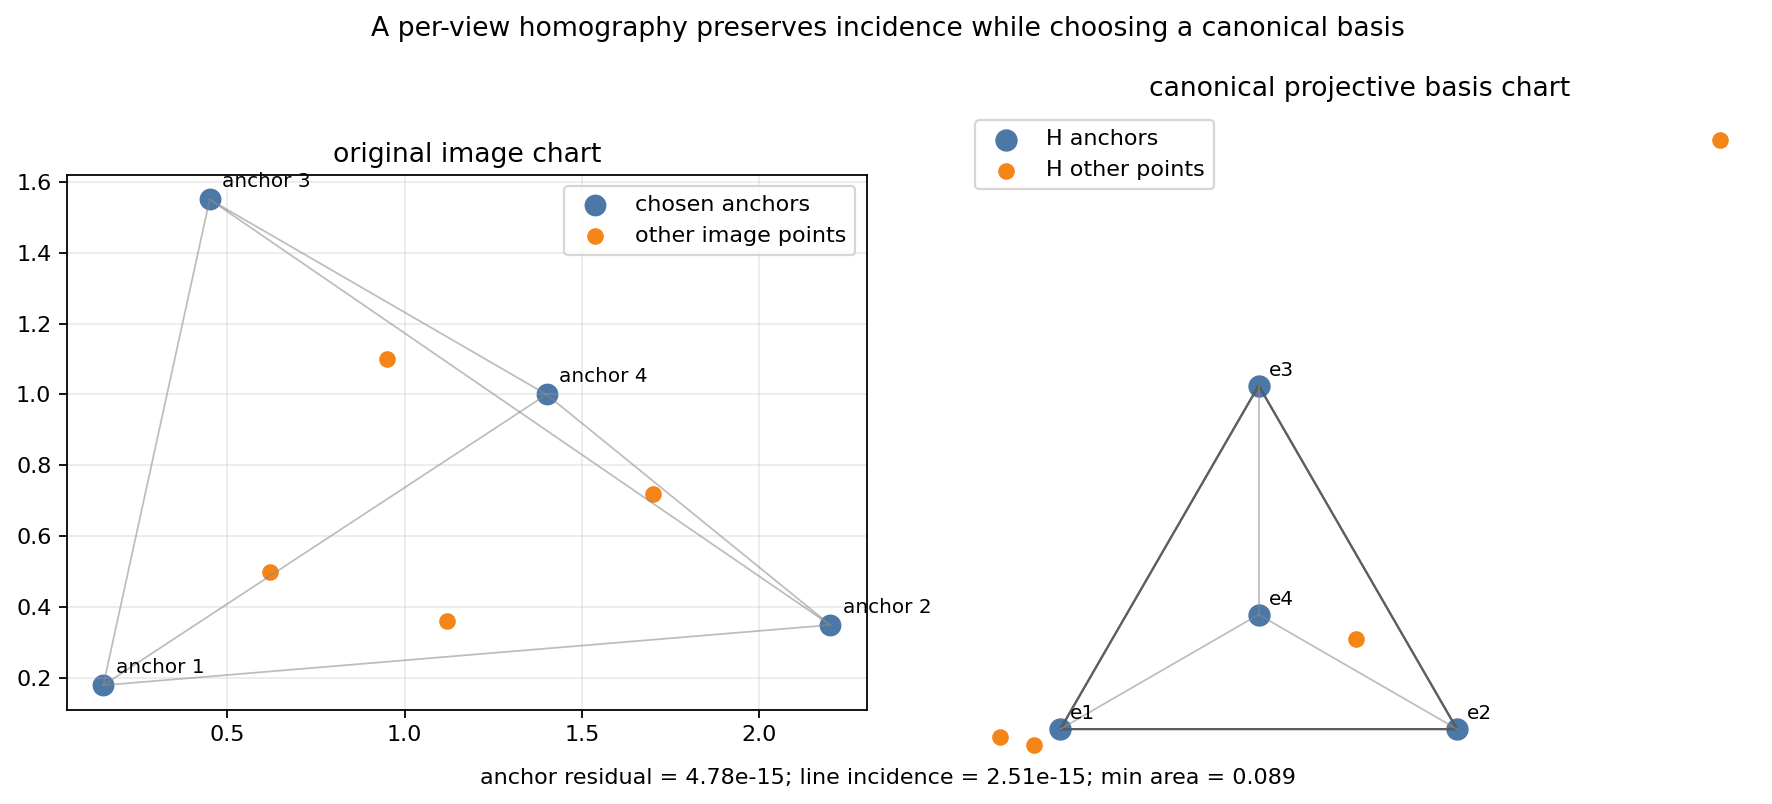

{'canonical_cross_residual': 4.775103669761791e-15,
 'canonical_line_residual': 2.5103574808520835e-15}

In [6]:
source_anchors = np.array([[0.15, 0.18, 1.0], [2.20, 0.35, 1.0], [0.45, 1.55, 1.0], [1.40, 1.00, 1.0]])
H_to_basis, H_dlt_singular_values = homography_from_homogeneous_points(source_anchors, E3_IMAGE)
mapped_anchors = (H_to_basis @ source_anchors.T).T
canonical_cross_residual = max(projective_cross_residual(mapped_anchors[i], E3_IMAGE[i]) for i in range(4))
source_min_area = min_anchor_triangle_area(source_anchors)

line_residuals_after = []
for i, j in itertools.combinations(range(4), 2):
    line_after = transformed_line(H_to_basis, np.cross(source_anchors[i], source_anchors[j]))
    for k in [i, j]:
        line_residuals_after.append(point_line_incidence(line_after, mapped_anchors[k]))
canonical_line_residual = max(line_residuals_after)

extra_points = np.array([[0.62, 0.50, 1.0], [1.12, 0.36, 1.0], [0.95, 1.10, 1.0], [1.70, 0.72, 1.0]])
mapped_extra = (H_to_basis @ extra_points.T).T

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.8))
source_xy = dehomogeneous(source_anchors)
extra_xy = dehomogeneous(extra_points)
axes[0].scatter(source_xy[:, 0], source_xy[:, 1], s=78, c="#4c78a8", label="chosen anchors")
axes[0].scatter(extra_xy[:, 0], extra_xy[:, 1], s=42, c="#f58518", label="other image points")
for idx, (x, y) in enumerate(source_xy, start=1):
    axes[0].text(x + 0.035, y + 0.035, f"anchor {idx}", fontsize=9)
for i, j in itertools.combinations(range(4), 2):
    axes[0].plot([source_xy[i, 0], source_xy[j, 0]], [source_xy[i, 1], source_xy[j, 1]], color="#888888", lw=0.8, alpha=0.55)
axes[0].set_title("original image chart")
axes[0].set_aspect("equal", adjustable="box")
axes[0].grid(alpha=0.25)
axes[0].legend(frameon=True)

triangle = np.vstack([TRIANGLE_CHART, TRIANGLE_CHART[0]])
axes[1].plot(triangle[:, 0], triangle[:, 1], color="#333333", lw=1.0)
canonical_xy = simplex_chart(mapped_anchors)
extra_canonical_xy = simplex_chart(mapped_extra)
axes[1].scatter(canonical_xy[:, 0], canonical_xy[:, 1], s=82, c="#4c78a8", label="H anchors")
axes[1].scatter(extra_canonical_xy[:, 0], extra_canonical_xy[:, 1], s=42, c="#f58518", label="H other points")
for idx, (x, y) in enumerate(canonical_xy, start=1):
    axes[1].text(x + 0.025, y + 0.025, f"e{idx}" if idx < 4 else "e4", fontsize=9)
for i, j in itertools.combinations(range(4), 2):
    axes[1].plot([canonical_xy[i, 0], canonical_xy[j, 0]], [canonical_xy[i, 1], canonical_xy[j, 1]], color="#888888", lw=0.8, alpha=0.55)
axes[1].set_title("canonical projective basis chart")
axes[1].set_aspect("equal", adjustable="box")
axes[1].axis("off")
axes[1].legend(frameon=True)
fig.suptitle("A per-view homography preserves incidence while choosing a canonical basis", y=1.02)
fig.text(0.5, 0.02, f"anchor residual = {canonical_cross_residual:.2e}; line incidence = {canonical_line_residual:.2e}; min area = {source_min_area:.3f}", ha="center")
fig.tight_layout()

canonical_path = save_matplotlib(fig, TOPIC, "figures", "canonical-frame-incidence-transform.png")
plt.close(fig)
artifact_paths.append(canonical_path)
display_artifact(canonical_path, width=900)

{"canonical_cross_residual": canonical_cross_residual, "canonical_line_residual": canonical_line_residual}

## 4. The Dual Algorithm Is a Transpose Plus Four Synthetic Rows

After canonicalization, the algorithm drops the four special rows, transposes the remaining `m by n` block, and appends four rows containing `e_1,...,e_4`. The synthetic rows force the reconstruction in the dual problem to use reduced cameras.

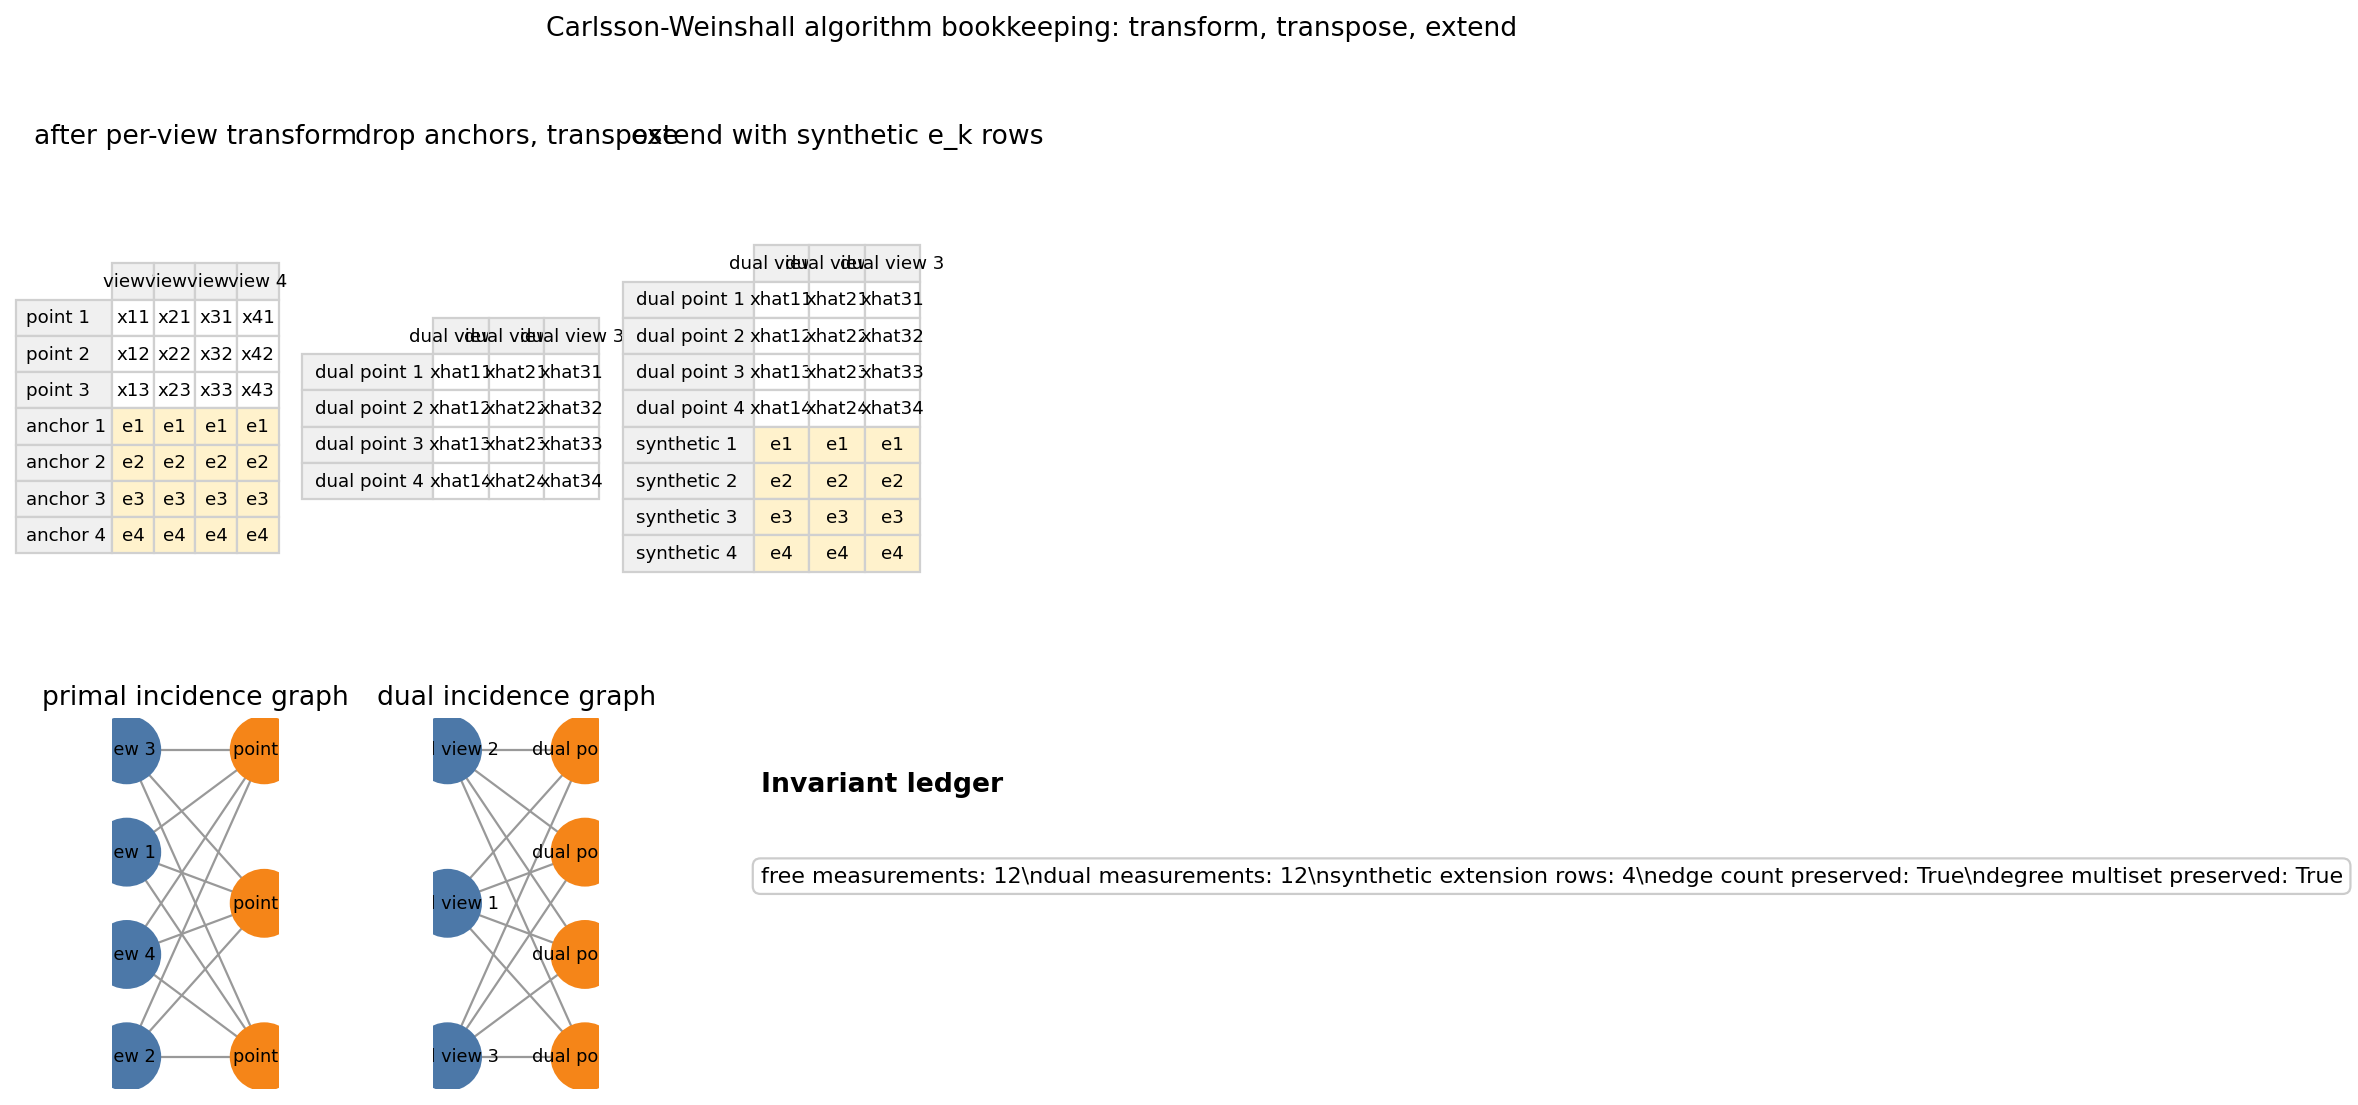

{'edge_count_preserved': True, 'degree_multiset_preserved': True}

In [7]:
m_views = 4
n_free_points = 3
original_table = [[f"x{i+1}{j+1}" for i in range(m_views)] for j in range(n_free_points)]
anchor_table = [[f"e{k+1}" for _ in range(m_views)] for k in range(4)]
transposed_table = [[f"xhat{j+1}{i+1}" for j in range(n_free_points)] for i in range(m_views)]
extended_table = transposed_table + [[f"e{k+1}" for _ in range(n_free_points)] for k in range(4)]

G = nx.Graph()
for i in range(m_views):
    G.add_node(f"view {i+1}", bipartite=0)
for j in range(n_free_points):
    G.add_node(f"point {j+1}", bipartite=1)
for i in range(m_views):
    for j in range(n_free_points):
        G.add_edge(f"view {i+1}", f"point {j+1}")
G_dual = nx.Graph()
for j in range(n_free_points):
    G_dual.add_node(f"dual view {j+1}", bipartite=0)
for i in range(m_views):
    G_dual.add_node(f"dual point {i+1}", bipartite=1)
for j in range(n_free_points):
    for i in range(m_views):
        G_dual.add_edge(f"dual view {j+1}", f"dual point {i+1}")
edge_count_preserved = G.number_of_edges() == G_dual.number_of_edges()
degree_multiset_preserved = sorted(dict(G.degree()).values()) == sorted(dict(G_dual.degree()).values())

def draw_table(ax, data, title, row_labels, col_labels, highlight_rows=()):
    ax.axis("off")
    table = ax.table(cellText=data, rowLabels=row_labels, colLabels=col_labels, loc="center", cellLoc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(8.2)
    table.scale(1.0, 1.22)
    highlight_rows = set(highlight_rows)
    for (r, c), cell in table.get_celld().items():
        cell.set_edgecolor("#d0d0d0")
        if r == 0 or c == -1:
            cell.set_facecolor("#f0f0f0")
        if r - 1 in highlight_rows and c >= 0:
            cell.set_facecolor("#fff2cc")
    ax.set_title(title)

fig = plt.figure(figsize=(13.0, 7.0))
gs = fig.add_gridspec(2, 3, height_ratios=[1.15, 0.85])
draw_table(fig.add_subplot(gs[0, 0]), original_table + anchor_table, "after per-view transform", [f"point {j+1}" for j in range(n_free_points)] + [f"anchor {k+1}" for k in range(4)], [f"view {i+1}" for i in range(m_views)], range(n_free_points, n_free_points + 4))
draw_table(fig.add_subplot(gs[0, 1]), transposed_table, "drop anchors, transpose", [f"dual point {i+1}" for i in range(m_views)], [f"dual view {j+1}" for j in range(n_free_points)])
draw_table(fig.add_subplot(gs[0, 2]), extended_table, "extend with synthetic e_k rows", [f"dual point {i+1}" for i in range(m_views)] + [f"synthetic {k+1}" for k in range(4)], [f"dual view {j+1}" for j in range(n_free_points)], range(m_views, m_views + 4))

ax3 = fig.add_subplot(gs[1, 0])
nx.draw_networkx(G, pos=nx.bipartite_layout(G, [f"view {i+1}" for i in range(m_views)]), ax=ax3, node_color=["#4c78a8" if n.startswith("view") else "#f58518" for n in G.nodes], font_size=8, edge_color="#999999", node_size=900)
ax3.set_title("primal incidence graph")
ax3.axis("off")
ax4 = fig.add_subplot(gs[1, 1])
nx.draw_networkx(G_dual, pos=nx.bipartite_layout(G_dual, [f"dual view {j+1}" for j in range(n_free_points)]), ax=ax4, node_color=["#4c78a8" if n.startswith("dual view") else "#f58518" for n in G_dual.nodes], font_size=8, edge_color="#999999", node_size=900)
ax4.set_title("dual incidence graph")
ax4.axis("off")
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis("off")
ax5.text(0.04, 0.80, "Invariant ledger", fontsize=12, fontweight="bold")
ax5.text(0.04, 0.60, f"free measurements: {m_views*n_free_points}//ndual measurements: {G_dual.number_of_edges()}//nsynthetic extension rows: 4//nedge count preserved: {edge_count_preserved}//ndegree multiset preserved: {degree_multiset_preserved}", va="top", bbox={"boxstyle": "round,pad=0.35", "fc": "white", "ec": "#cccccc"})
fig.suptitle("Carlsson-Weinshall algorithm bookkeeping: transform, transpose, extend", y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.95])

dual_algorithm_path = save_matplotlib(fig, TOPIC, "figures", "dual-algorithm-transpose-extend.png")
plt.close(fig)
artifact_paths.append(dual_algorithm_path)
display_artifact(dual_algorithm_path, width=940)

{"edge_count_preserved": edge_count_preserved, "degree_multiset_preserved": degree_multiset_preserved}

## 5. Reduced Fundamental Matrix as a Dual Tensor

A reduced fundamental matrix has already absorbed the four synthetic correspondences `e_k <-> e_k`. Its diagonal entries vanish and the sum of all entries vanishes. Each additional same-image dual correspondence contributes one linear equation in the five remaining parameters.

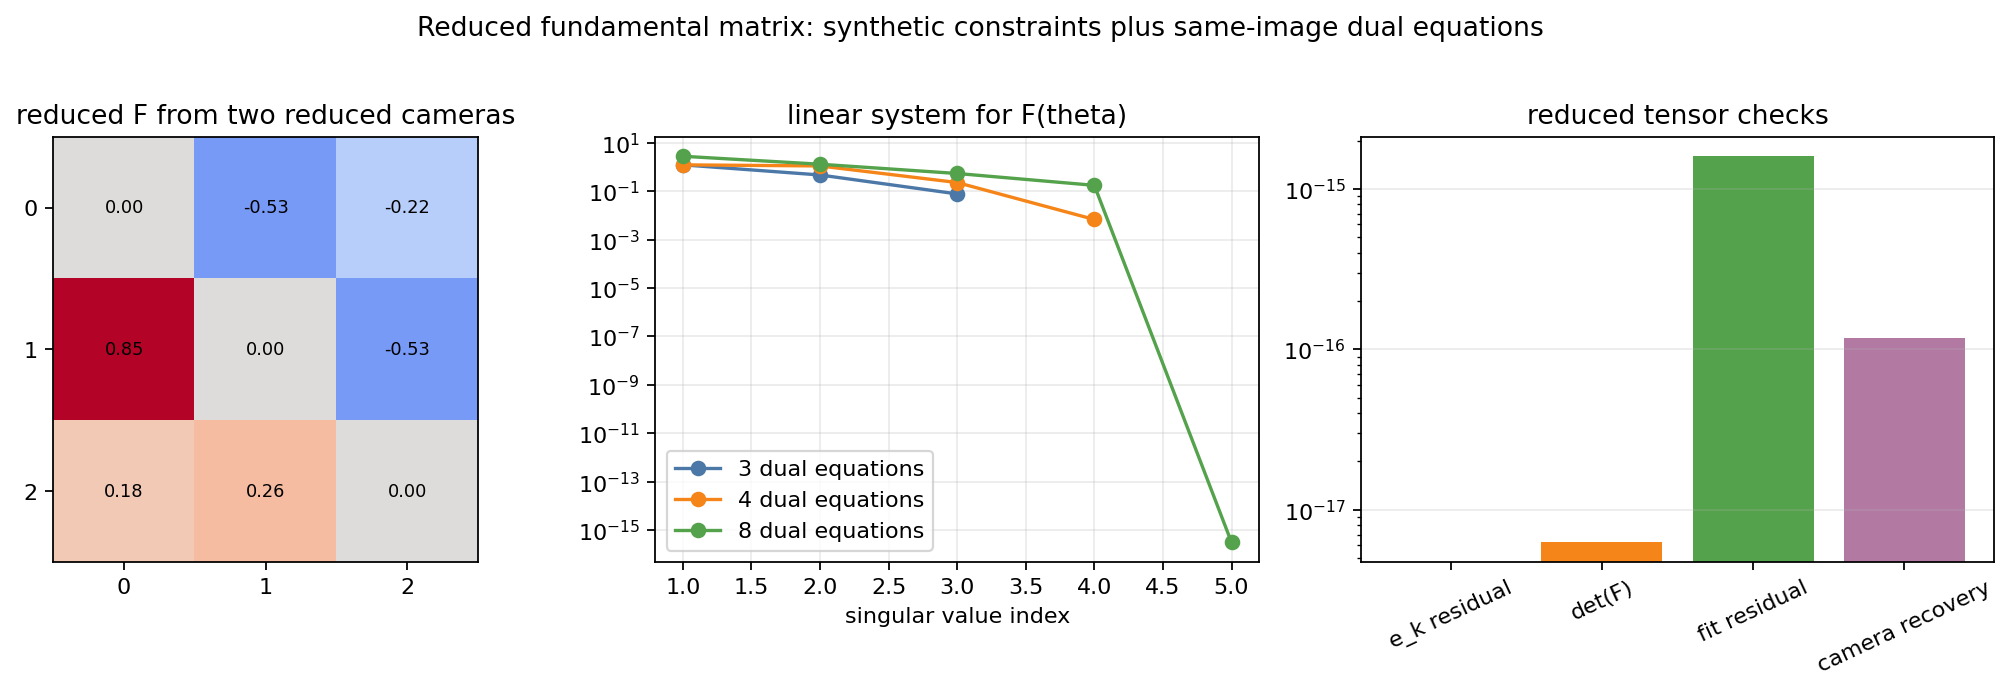

{'max_synthetic_e_residual': 0.0,
 'determinant': -6.256661855275067e-18,
 'F_est_scaled_relative_error': 6.660260507987852e-15,
 'max_dual_pair_residual': 1.5959455978986625e-15,
 'F_recovered_scaled_relative_error': 1.183640819208189e-16}

In [8]:
a, b, c, d = sp.symbols("a b c d")
F_sym = sp.Matrix([[0, b * (d - c), -c * (d - b)], [-a * (d - c), 0, c * (d - a)], [a * (d - b), -b * (d - a), 0]])
e_sym = [sp.Matrix([1, 0, 0]), sp.Matrix([0, 1, 0]), sp.Matrix([0, 0, 1]), sp.Matrix([1, 1, 1])]
symbolic_reduced_residuals = [sp.simplify((e.T * F_sym * e)[0]) for e in e_sym]
symbolic_det = sp.factor(F_sym.det())
assert all(value == 0 for value in symbolic_reduced_residuals)
assert symbolic_det == 0

F_true = reduced_F_from_camera_params(camera_params)
reduced_F_synthetic_residuals = [float(abs(e @ F_true @ e)) for e in E3_IMAGE]
reduced_F_det = float(np.linalg.det(F_true))

rng = np.random.default_rng(2020)
dual_pairs = []
for _ in range(8):
    x = np.array([rng.uniform(-0.75, 0.90), rng.uniform(-0.55, 0.70), 1.0])
    y = point_on_line(F_true @ x, rng.uniform(-0.65, 0.85))
    dual_pairs.append((x, y))
A_reduced_F = np.vstack([reduced_F_equation_row(x, y) for x, y in dual_pairs])
svd_by_view_count = {count: np.linalg.svd(A_reduced_F[:count], compute_uv=False) for count in [3, 4, 8]}
theta_est = null_vector(A_reduced_F[:4])
F_est_unscaled = reduced_F_template(theta_est)
F_est_error, F_est_scale = scaled_relative_error(F_est_unscaled, F_true)
F_est = F_est_scale * F_est_unscaled
reduced_pair_residuals = [float(abs(y @ F_est @ x)) for x, y in dual_pairs]
recovered_params = recover_reduced_camera_params_from_F(F_true)
F_recovered_error, _ = scaled_relative_error(reduced_F_from_camera_params(recovered_params), F_true)

fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.2), gridspec_kw={"width_ratios": [1.0, 1.05, 1.1]})
matrix_heatmap(axes[0], F_true, "reduced F from two reduced cameras")
for count, color in zip([3, 4, 8], ["#4c78a8", "#f58518", "#54a24b"]):
    values = svd_by_view_count[count]
    axes[1].semilogy(np.arange(1, len(values) + 1), values, marker="o", color=color, label=f"{count} dual equations")
axes[1].set_title("linear system for F(theta)")
axes[1].set_xlabel("singular value index")
axes[1].grid(alpha=0.25)
axes[1].legend(frameon=True)
axes[2].bar(["e_k residual", "det(F)", "fit residual", "camera recovery"], [max(reduced_F_synthetic_residuals), abs(reduced_F_det), max(reduced_pair_residuals), F_recovered_error], color=["#4c78a8", "#f58518", "#54a24b", "#b279a2"])
axes[2].set_yscale("log")
axes[2].set_title("reduced tensor checks")
axes[2].tick_params(axis="x", rotation=25)
axes[2].grid(axis="y", alpha=0.25)
fig.suptitle("Reduced fundamental matrix: synthetic constraints plus same-image dual equations", y=1.02)
fig.tight_layout()

reduced_F_path = save_matplotlib(fig, TOPIC, "figures", "reduced-fundamental-dual-tensor.png")
plt.close(fig)
artifact_paths.append(reduced_F_path)
display_artifact(reduced_F_path, width=940)

{"max_synthetic_e_residual": max(reduced_F_synthetic_residuals), "determinant": reduced_F_det, "F_est_scaled_relative_error": F_est_error, "max_dual_pair_residual": max(reduced_pair_residuals), "F_recovered_scaled_relative_error": F_recovered_error}

## 6. Reduced Trifocal Tensor Constraints

For seven points in many views, the dual route uses a reduced trifocal tensor. Unlike the reduced fundamental matrix, a convenient small parametrization is not obvious. The safe computational pattern is constrained least squares: synthetic correspondences define exact linear constraints `C t = 0`, and real correspondences define a data matrix whose residual is minimized inside that nullspace.

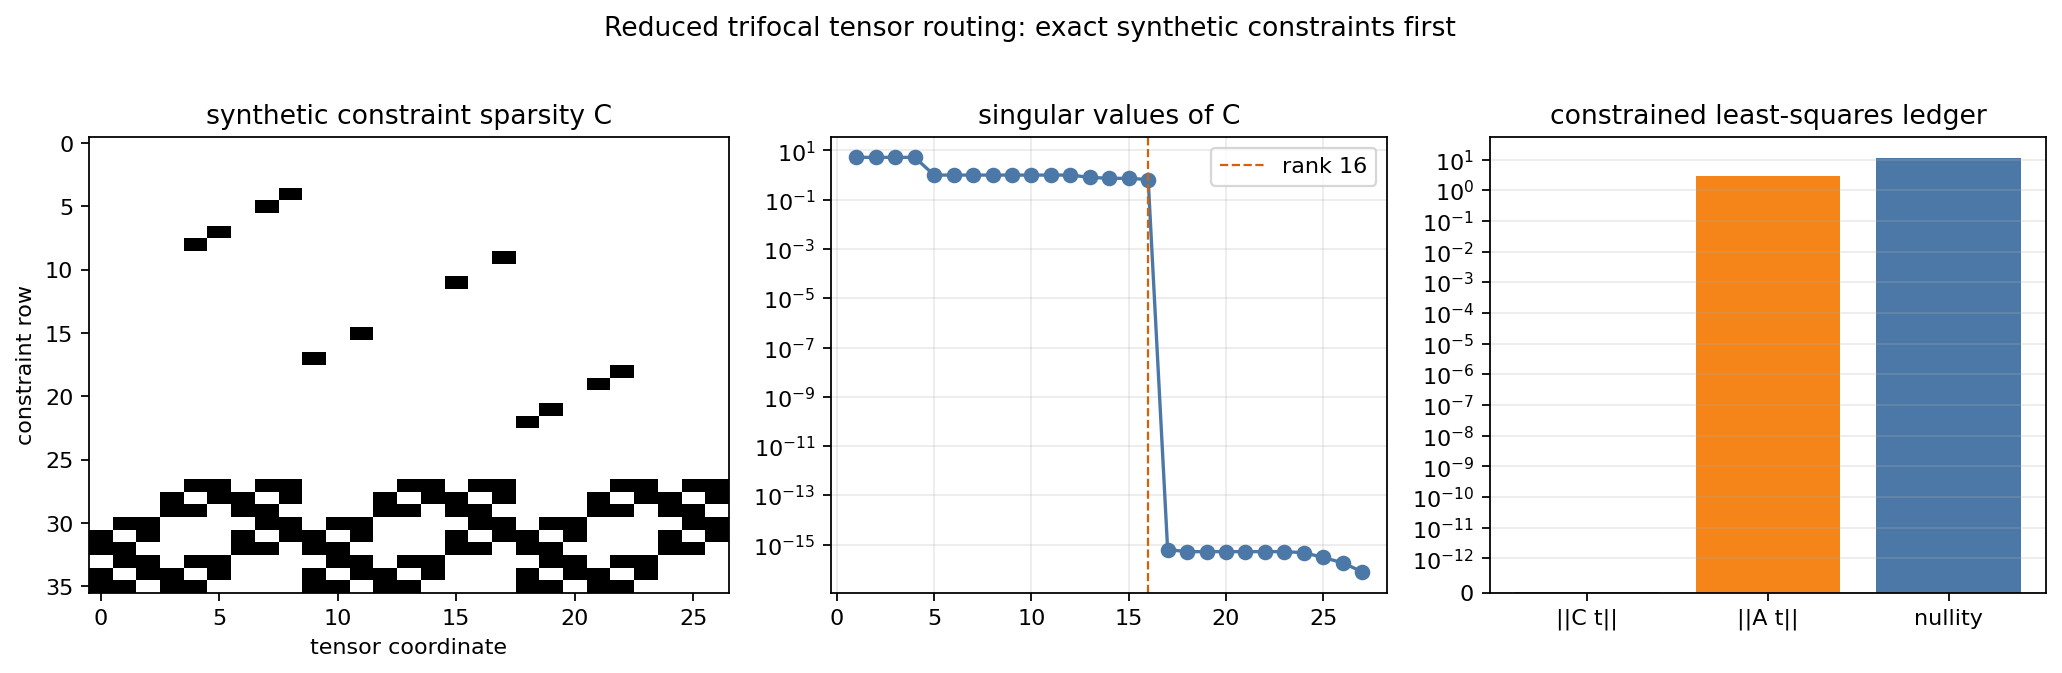

{'constraint_rows': 36,
 'constraint_columns': 27,
 'rank': 16,
 'nullity': 11,
 'exact_constraint_residual': 2.068162032035423e-15,
 'data_residual_inside_nullspace': 3.0285718333514073}

In [9]:
C_trifocal = np.vstack([trifocal_point_constraint_rows(e, e, e) for e in E3_IMAGE])
_, S_C, Vt_C = np.linalg.svd(C_trifocal)
trifocal_rank = int(np.sum(S_C > 1e-10))
trifocal_nullity = int(27 - trifocal_rank)
N_trifocal = Vt_C[trifocal_rank:].T

rng = np.random.default_rng(2042)
A_data = rng.normal(size=(34, 27))
projected_data = A_data @ N_trifocal
_, _, Vt_projected = np.linalg.svd(projected_data, full_matrices=False)
t_constrained = N_trifocal @ Vt_projected[-1]
trifocal_exact_constraint_residual = float(np.linalg.norm(C_trifocal @ t_constrained))
trifocal_data_residual = float(np.linalg.norm(A_data @ t_constrained))

fig, axes = plt.subplots(1, 3, figsize=(13.0, 4.1), gridspec_kw={"width_ratios": [1.15, 1.0, 1.0]})
axes[0].imshow(np.abs(C_trifocal) > 0, aspect="auto", cmap="Greys")
axes[0].set_title("synthetic constraint sparsity C")
axes[0].set_xlabel("tensor coordinate")
axes[0].set_ylabel("constraint row")
axes[1].semilogy(np.arange(1, len(S_C) + 1), S_C, marker="o", color="#4c78a8")
axes[1].axvline(trifocal_rank, color="#d95f02", ls="--", lw=1.0, label=f"rank {trifocal_rank}")
axes[1].set_title("singular values of C")
axes[1].grid(alpha=0.25)
axes[1].legend(frameon=True)
axes[2].bar(["||C t||", "||A t||", "nullity"], [trifocal_exact_constraint_residual, trifocal_data_residual, trifocal_nullity], color=["#54a24b", "#f58518", "#4c78a8"])
axes[2].set_yscale("symlog", linthresh=1e-12)
axes[2].set_title("constrained least-squares ledger")
axes[2].grid(axis="y", alpha=0.25)
fig.suptitle("Reduced trifocal tensor routing: exact synthetic constraints first", y=1.02)
fig.tight_layout()

trifocal_path = save_matplotlib(fig, TOPIC, "figures", "reduced-trifocal-constraint-nullspace.png")
plt.close(fig)
artifact_paths.append(trifocal_path)
display_artifact(trifocal_path, width=940)

{"constraint_rows": int(C_trifocal.shape[0]), "constraint_columns": int(C_trifocal.shape[1]), "rank": trifocal_rank, "nullity": trifocal_nullity, "exact_constraint_residual": trifocal_exact_constraint_residual, "data_residual_inside_nullspace": trifocal_data_residual}

## 7. Conditioning Lab: Canonical Transforms Can Distort Noise

The dualization recipe assumes each view can be sent to the canonical image basis using four chosen points. Geometrically this is fine when no three anchors are collinear. Numerically it can be dangerous when three anchors are nearly collinear. The lab below moves one anchor toward the line through two others and monitors the homography condition number.

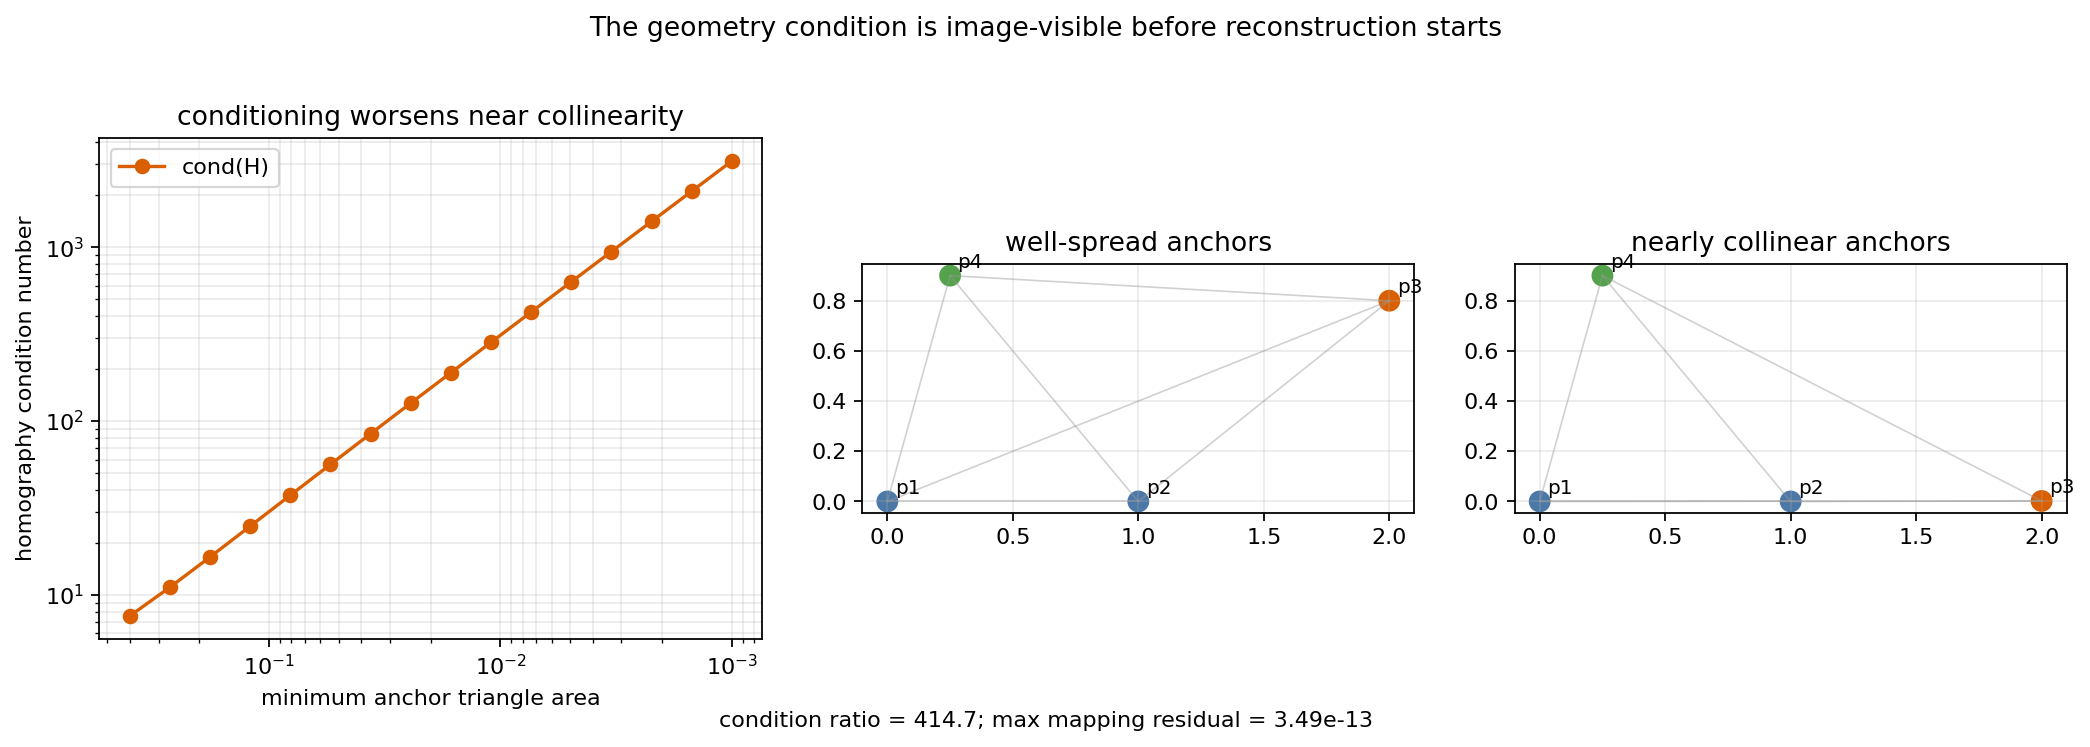

`artifacts/chapter-20/checks/canonical-transform-conditioning.json`

{'condition_ratio_near_collinear_to_well_spread': 414.74005143744137,
 'max_mapping_residual': 3.49495020325594e-13}

In [10]:
alpha_values = np.geomspace(0.002, 0.80, 16)
conditioning_rows = []
for alpha in alpha_values:
    anchors = np.array([[0.0, 0.0, 1.0], [1.0, 0.0, 1.0], [2.0, alpha, 1.0], [0.25, 0.90, 1.0]])
    H_alpha, singular_values_alpha = homography_from_homogeneous_points(anchors, E3_IMAGE)
    mapped = (H_alpha @ anchors.T).T
    conditioning_rows.append({
        "alpha": float(alpha),
        "min_triangle_area": min_anchor_triangle_area(anchors),
        "homography_condition": float(np.linalg.cond(H_alpha / max(np.linalg.norm(H_alpha), 1e-15))),
        "mapping_residual": max(projective_cross_residual(mapped[i], E3_IMAGE[i]) for i in range(4)),
        "dlt_gap": float(singular_values_alpha[-2] / max(singular_values_alpha[-1], 1e-15)),
    })

areas = np.array([row["min_triangle_area"] for row in conditioning_rows])
conditions = np.array([row["homography_condition"] for row in conditioning_rows])
residuals = np.array([row["mapping_residual"] for row in conditioning_rows])
condition_ratio = float(conditions[0] / conditions[-1])

fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.4), gridspec_kw={"width_ratios": [1.2, 1.0, 1.0]})
axes[0].loglog(areas, conditions, marker="o", color="#d95f02", label="cond(H)")
axes[0].invert_xaxis()
axes[0].set_xlabel("minimum anchor triangle area")
axes[0].set_ylabel("homography condition number")
axes[0].set_title("conditioning worsens near collinearity")
axes[0].grid(alpha=0.25, which="both")
axes[0].legend(frameon=True)

def draw_anchor_set(ax, anchors, title):
    xy = dehomogeneous(anchors)
    ax.scatter(xy[:, 0], xy[:, 1], s=78, c=["#4c78a8", "#4c78a8", "#d95f02", "#54a24b"])
    for i, (x, y) in enumerate(xy, start=1):
        ax.text(x + 0.03, y + 0.03, f"p{i}", fontsize=9)
    for i, j in itertools.combinations(range(4), 2):
        ax.plot([xy[i, 0], xy[j, 0]], [xy[i, 1], xy[j, 1]], color="#999999", lw=0.75, alpha=0.45)
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.25)

draw_anchor_set(axes[1], np.array([[0.0, 0.0, 1.0], [1.0, 0.0, 1.0], [2.0, 0.80, 1.0], [0.25, 0.90, 1.0]]), "well-spread anchors")
draw_anchor_set(axes[2], np.array([[0.0, 0.0, 1.0], [1.0, 0.0, 1.0], [2.0, 0.002, 1.0], [0.25, 0.90, 1.0]]), "nearly collinear anchors")
fig.suptitle("The geometry condition is image-visible before reconstruction starts", y=1.02)
fig.text(0.5, 0.01, f"condition ratio = {condition_ratio:.1f}; max mapping residual = {residuals.max():.2e}", ha="center")
fig.tight_layout()

conditioning_path = save_matplotlib(fig, TOPIC, "figures", "canonical-transform-conditioning.png")
plt.close(fig)
artifact_paths.append(conditioning_path)
display_artifact(conditioning_path, width=940)

conditioning_table_path = save_json(conditioning_rows, TOPIC, "checks", "canonical-transform-conditioning.json")
check_paths.append(conditioning_table_path)
display_artifact(conditioning_table_path)

{"condition_ratio_near_collinear_to_well_spread": condition_ratio, "max_mapping_residual": float(residuals.max())}

## Applied Lab

Use this notebook as a diagnostic harness before trying a dual reconstruction on measured tracks:

1. Choose four candidate anchor tracks and compute the minimum triangle area in every image.
2. Canonicalize each view and check the cross-product residual to `e_1,...,e_4`.
3. Build the transposed dual array and decide whether the target solver needs synthetic rows or can enforce reduced camera constraints directly.
4. For six-point experiments, estimate a reduced fundamental matrix from same-image dual correspondences and inspect the singular values of the linear system.
5. For seven-point experiments, keep the synthetic trifocal constraints exact and minimize data residuals only inside their nullspace.

In [11]:
duality_invariants = {
    "source_span": "PDF pages 520-532, printed pages 502-514",
    "dual_swap_residual": dual_swap_residual,
    "basis_projection_residual_max": float(max(basis_projection_residuals)),
    "point_plane_camera_incidence": {
        "max_image_line_residual": float(max(image_line_residuals)),
        "max_backprojected_plane_residual": float(max(plane_incidence_residuals)),
    },
    "canonical_transform": {
        "anchor_cross_residual": canonical_cross_residual,
        "line_incidence_residual": canonical_line_residual,
        "min_anchor_triangle_area": source_min_area,
    },
    "dual_algorithm": {
        "edge_count_preserved": edge_count_preserved,
        "degree_multiset_preserved": degree_multiset_preserved,
        "free_measurement_count": m_views * n_free_points,
        "synthetic_extension_count": 4 * n_free_points,
    },
    "reduced_fundamental_matrix": {
        "synthetic_e_residual_max": float(max(reduced_F_synthetic_residuals)),
        "determinant_abs": float(abs(reduced_F_det)),
        "estimated_F_scaled_relative_error": F_est_error,
        "dual_pair_residual_max": float(max(reduced_pair_residuals)),
        "recovered_camera_F_scaled_relative_error": F_recovered_error,
    },
    "reduced_trifocal_constraints": {
        "constraint_rank": trifocal_rank,
        "constraint_nullity": trifocal_nullity,
        "exact_constraint_residual": trifocal_exact_constraint_residual,
    },
    "conditioning_lab": {
        "condition_ratio_near_collinear_to_well_spread": condition_ratio,
        "max_mapping_residual": float(residuals.max()),
    },
    "artifacts": [path.relative_to(BOOK_ROOT).as_posix() for path in artifact_paths],
}
invariants_path = save_json(duality_invariants, TOPIC, "checks", "duality-invariants.json")
check_paths.append(invariants_path)
display_artifact(invariants_path)
duality_invariants

`artifacts/chapter-20/checks/duality-invariants.json`

{'source_span': 'PDF pages 520-532, printed pages 502-514',
 'dual_swap_residual': 0.0,
 'basis_projection_residual_max': 0.0,
 'point_plane_camera_incidence': {'max_image_line_residual': 0.0,
  'max_backprojected_plane_residual': 5.551115123125783e-17},
 'canonical_transform': {'anchor_cross_residual': 4.775103669761791e-15,
  'line_incidence_residual': 2.5103574808520835e-15,
  'min_anchor_triangle_area': 0.08874999999999979},
 'dual_algorithm': {'edge_count_preserved': True,
  'degree_multiset_preserved': True,
  'free_measurement_count': 12,
  'synthetic_extension_count': 12},
 'reduced_fundamental_matrix': {'synthetic_e_residual_max': 0.0,
  'determinant_abs': 6.256661855275067e-18,
  'estimated_F_scaled_relative_error': 6.660260507987852e-15,
  'dual_pair_residual_max': 1.5959455978986625e-15,
  'recovered_camera_F_scaled_relative_error': 1.183640819208189e-16},
 'reduced_trifocal_constraints': {'constraint_rank': 16,
  'constraint_nullity': 11,
  'exact_constraint_residual': 2.0

## Final Sanity Checks

The final cell asserts the chapter's executable contract: artifacts exist, core incidence identities hold, reduced tensor constraints are numerically small, and the conditioning lab detects the near-collinearity risk.

In [12]:
assert_artifacts(artifact_paths, min_bytes=1500)
assert_artifacts(check_paths, min_bytes=32)

assert dual_swap_residual < 1e-12
assert max(basis_projection_residuals) < 1e-12
assert max(image_line_residuals) < 1e-12
assert max(plane_incidence_residuals) < 1e-12
assert canonical_cross_residual < 1e-12
assert canonical_line_residual < 1e-12
assert edge_count_preserved and degree_multiset_preserved
assert max(reduced_F_synthetic_residuals) < 1e-12
assert abs(reduced_F_det) < 1e-12
assert F_est_error < 1e-10
assert max(reduced_pair_residuals) < 1e-10
assert F_recovered_error < 1e-10
assert trifocal_exact_constraint_residual < 1e-10
assert condition_ratio > 100.0
assert float(residuals.max()) < 1e-10

final_sanity_path = ARTIFACT_ROOT / "checks" / "final-sanity.json"
final_check_files = [path.relative_to(BOOK_ROOT).as_posix() for path in check_paths] + [final_sanity_path.relative_to(BOOK_ROOT).as_posix()]
final_sanity = {
    "artifact_count": len(artifact_paths),
    "check_file_count": len(final_check_files),
    "dual_swap_residual": dual_swap_residual,
    "canonical_cross_residual": canonical_cross_residual,
    "canonical_line_residual": canonical_line_residual,
    "reduced_F_estimated_error": F_est_error,
    "trifocal_exact_constraint_residual": trifocal_exact_constraint_residual,
    "conditioning_ratio": condition_ratio,
    "artifact_files": [path.relative_to(BOOK_ROOT).as_posix() for path in artifact_paths],
    "check_files": final_check_files,
}
save_json(final_sanity, TOPIC, "checks", "final-sanity.json")
assert_artifacts([final_sanity_path], min_bytes=32)
display_artifact(final_sanity_path)
final_sanity

`artifacts/chapter-20/checks/final-sanity.json`

{'artifact_count': 7,
 'check_file_count': 4,
 'dual_swap_residual': 0.0,
 'canonical_cross_residual': 4.775103669761791e-15,
 'canonical_line_residual': 2.5103574808520835e-15,
 'reduced_F_estimated_error': 6.660260507987852e-15,
 'trifocal_exact_constraint_residual': 2.068162032035423e-15,
 'conditioning_ratio': 414.74005143744137,
 'artifact_files': ['artifacts/chapter-20/figures/reduced-camera-dual-swap.png',
  'artifacts/chapter-20/interactive/point-plane-camera-incidence.html',
  'artifacts/chapter-20/figures/canonical-frame-incidence-transform.png',
  'artifacts/chapter-20/figures/dual-algorithm-transpose-extend.png',
  'artifacts/chapter-20/figures/reduced-fundamental-dual-tensor.png',
  'artifacts/chapter-20/figures/reduced-trifocal-constraint-nullspace.png',
  'artifacts/chapter-20/figures/canonical-transform-conditioning.png'],
 'check_files': ['artifacts/chapter-20/checks/visual-storyboard.json',
  'artifacts/chapter-20/checks/canonical-transform-conditioning.json',
  'arti

## Takeaways

- Carlsson-Weinshall duality becomes concrete only after fixing reduced camera coordinates; then a camera parameter vector and a world point can exchange algebraic roles.
- The dual algorithm is mostly disciplined relabeling: canonicalize each image, transpose the free measurement block, extend with four synthetic basis rows, solve the dual reconstruction, then map back.
- Incidence is the invariant that survives the relabeling. Image lines through a measured point back-project to planes through the 3D point and camera center.
- Reduced fundamental matrices have an explicit five-parameter template; reduced trifocal tensors are better treated as constrained least-squares objects with exact synthetic constraints.
- The practical failure mode is conditioning. Nearly collinear anchors may satisfy the projective geometry but still make the transformed measurement domain a poor place to measure error.